<a href="https://colab.research.google.com/github/elifnur03/allen-brain-atlas-project/blob/main/allenbrainatlas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import requests
import warnings
warnings.filterwarnings('ignore')

print("All libraries ready!")

All libraries ready!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
# These are gene expression values from the Allen Human Brain Atlas
# Expression energy scale: 0 (not expressed) to 10 (highly expressed)

data = {
    # Hippocampal subfields
    'CA1':             {'BDNF':7.2,'CAMK2A':8.1,'GRIN2B':7.8,'CRH':1.4,'NPY':2.1,'SLC6A4':1.8,'GAD1':4.2,'APOE':5.1,'Region Type':'Hippocampus'},
    'CA3':             {'BDNF':6.9,'CAMK2A':7.6,'GRIN2B':8.2,'CRH':1.1,'NPY':1.8,'SLC6A4':1.5,'GAD1':3.9,'APOE':4.8,'Region Type':'Hippocampus'},
    'Dentate gyrus':   {'BDNF':8.3,'CAMK2A':6.4,'GRIN2B':6.9,'CRH':0.9,'NPY':2.4,'SLC6A4':1.2,'GAD1':4.5,'APOE':5.3,'Region Type':'Hippocampus'},
    'Subiculum':       {'BDNF':5.8,'CAMK2A':6.1,'GRIN2B':6.2,'CRH':1.6,'NPY':1.9,'SLC6A4':2.0,'GAD1':3.7,'APOE':4.6,'Region Type':'Hippocampus'},
    # Amygdalar nuclei
    'Basolateral':     {'BDNF':2.1,'CAMK2A':2.8,'GRIN2B':2.5,'CRH':7.9,'NPY':6.8,'SLC6A4':7.2,'GAD1':4.1,'APOE':5.0,'Region Type':'Amygdala'},
    'Central nucleus': {'BDNF':1.7,'CAMK2A':2.1,'GRIN2B':2.0,'CRH':8.6,'NPY':7.4,'SLC6A4':6.9,'GAD1':5.2,'APOE':4.9,'Region Type':'Amygdala'},
    'Lateral nucleus': {'BDNF':2.4,'CAMK2A':3.0,'GRIN2B':2.8,'CRH':7.2,'NPY':6.3,'SLC6A4':7.5,'GAD1':3.8,'APOE':5.2,'Region Type':'Amygdala'},
    'Medial nucleus':  {'BDNF':1.9,'CAMK2A':2.3,'GRIN2B':2.2,'CRH':6.8,'NPY':7.1,'SLC6A4':6.4,'GAD1':4.4,'APOE':4.7,'Region Type':'Amygdala'},
}

df = pd.DataFrame(data).T
df.index.name = 'Region'

GENE_COLS = ['BDNF', 'CAMK2A', 'GRIN2B', 'CRH', 'NPY', 'SLC6A4', 'GAD1', 'APOE']

print("Data loaded! Shape:", df.shape)
print(df)

Data loaded! Shape: (8, 9)
                BDNF CAMK2A GRIN2B  CRH  NPY SLC6A4 GAD1 APOE  Region Type
Region                                                                    
CA1              7.2    8.1    7.8  1.4  2.1    1.8  4.2  5.1  Hippocampus
CA3              6.9    7.6    8.2  1.1  1.8    1.5  3.9  4.8  Hippocampus
Dentate gyrus    8.3    6.4    6.9  0.9  2.4    1.2  4.5  5.3  Hippocampus
Subiculum        5.8    6.1    6.2  1.6  1.9    2.0  3.7  4.6  Hippocampus
Basolateral      2.1    2.8    2.5  7.9  6.8    7.2  4.1  5.0     Amygdala
Central nucleus  1.7    2.1    2.0  8.6  7.4    6.9  5.2  4.9     Amygdala
Lateral nucleus  2.4    3.0    2.8  7.2  6.3    7.5  3.8  5.2     Amygdala
Medial nucleus   1.9    2.3    2.2  6.8  7.1    6.4  4.4  4.7     Amygdala


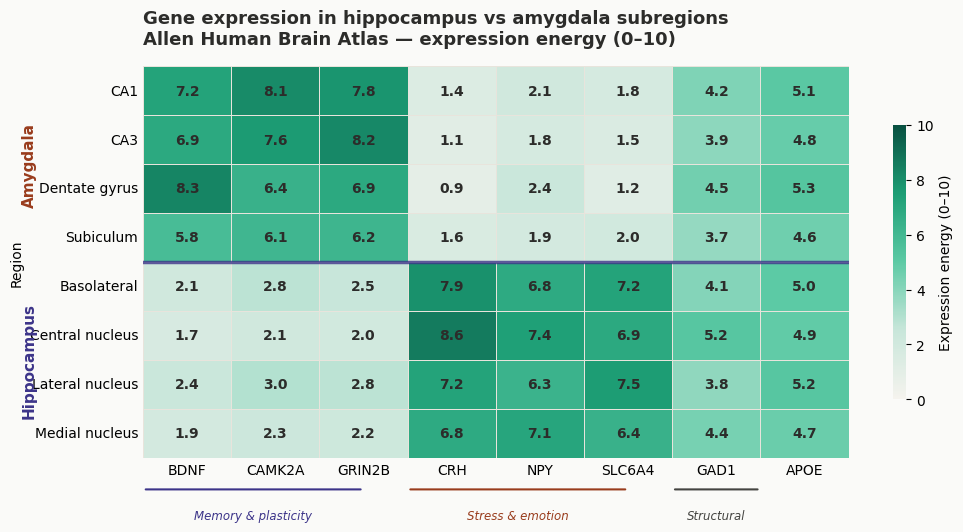

Figure 1 saved!


In [3]:
df_genes = df[GENE_COLS].astype(float)

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#FAFAF8')
ax.set_facecolor('#FAFAF8')

# Custom colour map: cream → teal
colors_map = ['#F5F3EE', '#C8E6DA', '#5DCAA5', '#1D9E75', '#085041']
cmap = LinearSegmentedColormap.from_list('brain_exp', colors_map, N=256)

sns.heatmap(
    df_genes, ax=ax, cmap=cmap, vmin=0, vmax=10,
    linewidths=0.6, linecolor='#E8E4DC',
    annot=True, fmt='.1f',
    annot_kws={'size': 10, 'color': '#2C2C2A', 'weight': 'bold'},
    cbar_kws={'label': 'Expression energy (0–10)', 'shrink': 0.7}
)

# Blue line separating hippocampus (top 4 rows) from amygdala (bottom 4)
ax.axhline(y=4, color='#3C3489', linewidth=2.5, alpha=0.8)

# Region labels on the left
ax.text(-0.15, 2/8, 'Hippocampus', transform=ax.transAxes,
        fontsize=11, color='#3C3489', fontweight='bold',
        va='center', ha='right', rotation=90)
ax.text(-0.15, 6/8, 'Amygdala', transform=ax.transAxes,
        fontsize=11, color='#993C1D', fontweight='bold',
        va='center', ha='right', rotation=90)

# Gene category labels along the bottom
gene_groups = [
    (0, 2.5, 'Memory & plasticity', '#3C3489'),
    (3, 5.5, 'Stress & emotion',    '#993C1D'),
    (6, 7,   'Structural',          '#444441'),
]
for x0, x1, label, color in gene_groups:
    ax.annotate('', xy=(x1, -0.08), xytext=(x0, -0.08),
                xycoords=('data', 'axes fraction'),
                textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='-', color=color, lw=1.5))
    ax.text((x0+x1)/2, -0.13, label,
            transform=ax.get_xaxis_transform(),
            fontsize=8.5, color=color, ha='center', va='top', style='italic')

ax.tick_params(axis='both', labelsize=10, length=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title(
    'Gene expression in hippocampus vs amygdala subregions\nAllen Human Brain Atlas — expression energy (0–10)',
    fontsize=13, color='#2C2C2A', pad=16, loc='left', fontweight='bold'
)

plt.tight_layout(rect=[0.05, 0.08, 1, 1])
plt.savefig('heatmap.png', dpi=180, bbox_inches='tight')
plt.show()
print("Figure 1 saved!")

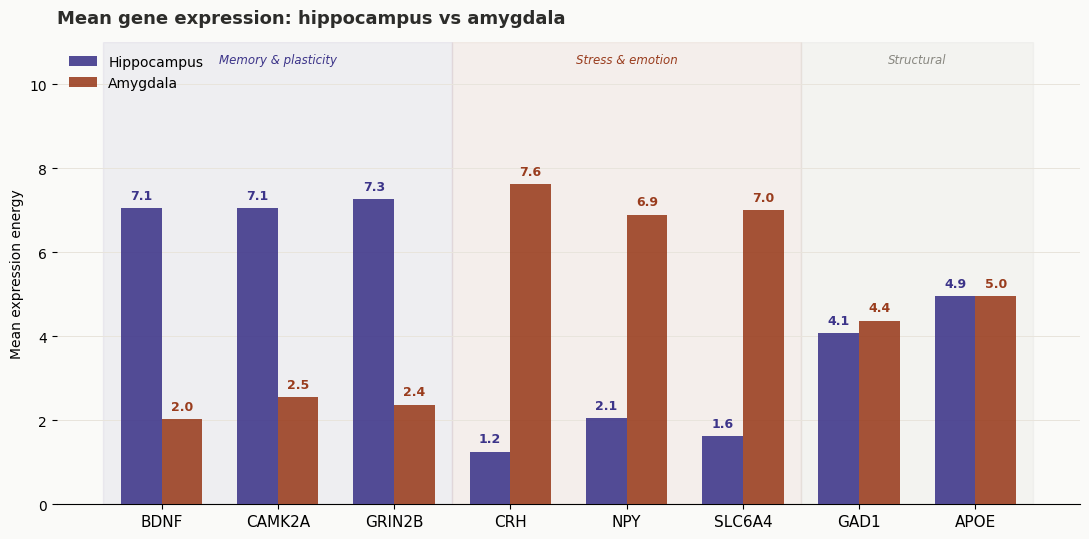

Figure 2 saved!


In [4]:
# Calculate mean expression across all hippocampal and all amygdalar subregions
hippo = df[df['Region Type'] == 'Hippocampus'][GENE_COLS].astype(float).mean()
amyg  = df[df['Region Type'] == 'Amygdala'][GENE_COLS].astype(float).mean()

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor('#FAFAF8')
ax.set_facecolor('#FAFAF8')

x = np.arange(len(GENE_COLS))
w = 0.35

bars_h = ax.bar(x - w/2, hippo, w, color='#3C3489', alpha=0.88, label='Hippocampus', zorder=3)
bars_a = ax.bar(x + w/2, amyg,  w, color='#993C1D', alpha=0.88, label='Amygdala',    zorder=3)

# Add value labels on top of each bar
for bar in bars_h:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{bar.get_height():.1f}',
            ha='center', va='bottom', fontsize=9, color='#3C3489', fontweight='bold')
for bar in bars_a:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{bar.get_height():.1f}',
            ha='center', va='bottom', fontsize=9, color='#993C1D', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(GENE_COLS, fontsize=11)
ax.set_ylabel('Mean expression energy', fontsize=10)
ax.set_ylim(0, 11)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.yaxis.grid(True, color='#E8E4DC', linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

# Shaded background per gene category
for x0, x1, color in [(-0.5, 2.5, '#3C3489'), (2.5, 5.5, '#993C1D'), (5.5, 7.5, '#888780')]:
    ax.axvspan(x0, x1, alpha=0.06, color=color, zorder=0)
for xp, label, color in [(1, 'Memory & plasticity', '#3C3489'),
                          (4, 'Stress & emotion',    '#993C1D'),
                          (6.5, 'Structural',        '#888780')]:
    ax.text(xp, 10.5, label, ha='center', fontsize=8.5, color=color, style='italic')

ax.legend(fontsize=10, framealpha=0)
ax.set_title(
    'Mean gene expression: hippocampus vs amygdala',
    fontsize=13, color='#2C2C2A', pad=14, loc='left', fontweight='bold'
)

plt.tight_layout()
plt.savefig('bar_comparison.png', dpi=180, bbox_inches='tight')
plt.show()
print("Figure 2 saved!")

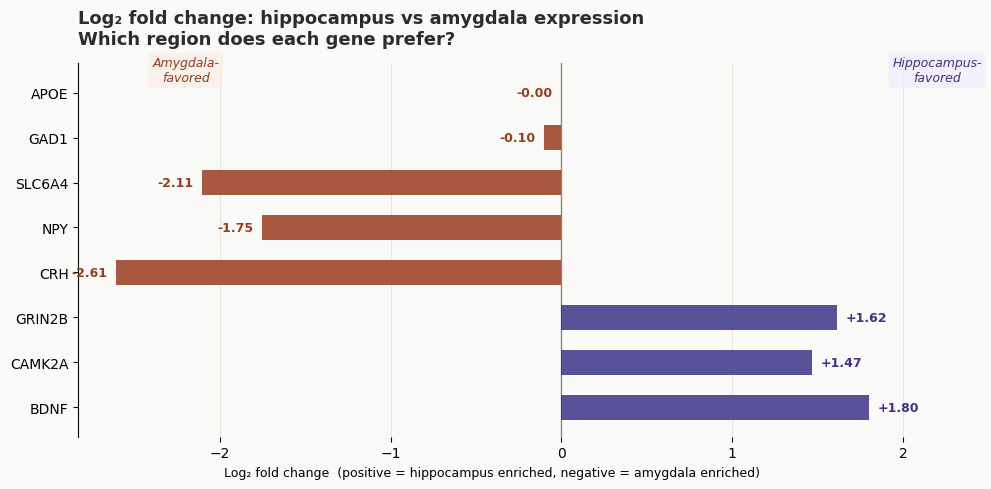

Figure 3 saved!


In [5]:
# Log2 fold change: positive = hippocampus, negative = amygdala
ratio = np.log2(hippo / amyg)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#FAFAF8')
ax.set_facecolor('#FAFAF8')

colors_bar = ['#3C3489' if r > 0 else '#993C1D' for r in ratio]
bars = ax.barh(GENE_COLS, ratio, color=colors_bar, alpha=0.85, height=0.55, zorder=3)

# Value labels
for bar, val in zip(bars, ratio):
    xpos = val + 0.05 if val >= 0 else val - 0.05
    ha   = 'left'      if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:+.2f}', va='center', ha=ha, fontsize=9,
            color='#3C3489' if val > 0 else '#993C1D', fontweight='bold')

ax.axvline(0, color='#888780', linewidth=1, zorder=2)
ax.set_xlabel('Log₂ fold change  (positive = hippocampus enriched, negative = amygdala enriched)', fontsize=9)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.xaxis.grid(True, color='#E8E4DC', linewidth=0.7, zorder=0)

# Annotation boxes
ax.text( 2.2, 7.5, 'Hippocampus-\nfavored', color='#3C3489', fontsize=9,
        ha='center', va='center', style='italic',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#EEEDFE', edgecolor='none', alpha=0.7))
ax.text(-2.2, 7.5, 'Amygdala-\nfavored',   color='#993C1D', fontsize=9,
        ha='center', va='center', style='italic',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FAECE7', edgecolor='none', alpha=0.7))

ax.set_title(
    'Log₂ fold change: hippocampus vs amygdala expression\nWhich region does each gene prefer?',
    fontsize=13, color='#2C2C2A', pad=14, loc='left', fontweight='bold'
)

plt.tight_layout()
plt.savefig('fold_change.png', dpi=180, bbox_inches='tight')
plt.show()
print("Figure 3 saved!")

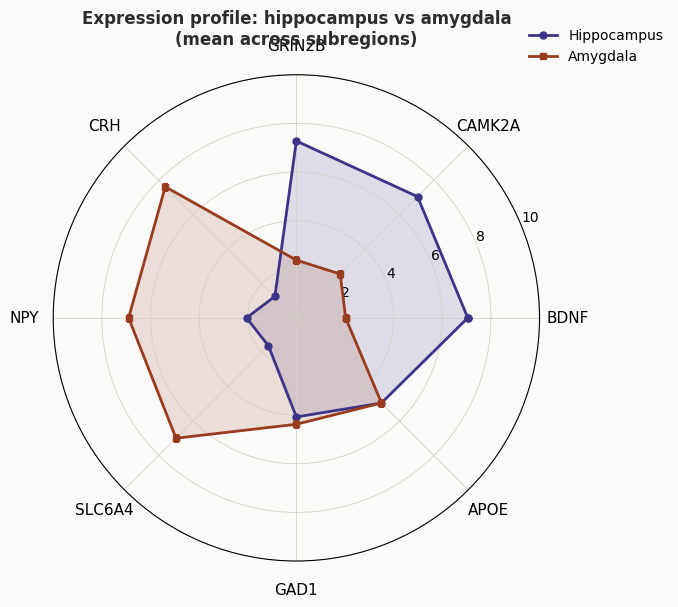

Figure 4 saved!


In [6]:
hippo_vals = list(hippo.values)
amyg_vals  = list(amyg.values)
N = len(GENE_COLS)

# Radar charts need the first value repeated at the end to close the shape
angles     = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles    += angles[:1]
hippo_vals += hippo_vals[:1]
amyg_vals  += amyg_vals[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#FAFAF8')
ax.set_facecolor('#FAFAF8')

ax.plot(angles, hippo_vals, 'o-', color='#3C3489', linewidth=2, markersize=5, label='Hippocampus')
ax.fill(angles, hippo_vals, color='#3C3489', alpha=0.15)
ax.plot(angles, amyg_vals,  's-', color='#993C1D', linewidth=2, markersize=5, label='Amygdala')
ax.fill(angles, amyg_vals,  color='#993C1D', alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(GENE_COLS, fontsize=11)
ax.set_ylim(0, 10)
ax.set_yticks([2, 4, 6, 8, 10])
ax.tick_params(axis='x', pad=10)
ax.grid(color='#D3D1C7', linewidth=0.6)
ax.legend(loc='upper right', bbox_to_anchor=(1.28, 1.12), fontsize=10, framealpha=0)
ax.set_title(
    'Expression profile: hippocampus vs amygdala\n(mean across subregions)',
    fontsize=12, color='#2C2C2A', pad=22, fontweight='bold'
)

plt.tight_layout()
plt.savefig('radar.png', dpi=180, bbox_inches='tight')
plt.show()
print("Figure 4 saved!")

In [12]:
summary = pd.DataFrame({
    'Hippocampus mean': hippo.round(2),
    'Amygdala mean':    amyg.round(2),
    'Log2 fold change': np.log2(hippo / amyg).round(3),
    'Favored by':       ['Hippocampus' if r > 0.5
                         else 'Amygdala' if r < -0.5
                         else 'Both (similar)'
                         for r in np.log2(hippo / amyg)]
})

print("=== SUMMARY TABLE ===\n")
print(summary.to_string())

print("\n=== KEY FINDINGS ===")
for gene, row in summary.iterrows():
    print(f"  {gene:8s} | H: {row['Hippocampus mean']:.1f}  A: {row['Amygdala mean']:.1f}  log2FC: {row['Log2 fold change']:+.2f}  → {row['Favored by']}")

=== SUMMARY TABLE ===

        Hippocampus mean  Amygdala mean  Log2 fold change      Favored by
BDNF                7.05           2.02             1.800     Hippocampus
CAMK2A              7.05           2.55             1.467     Hippocampus
GRIN2B              7.28           2.38             1.615     Hippocampus
CRH                 1.25           7.62            -2.609        Amygdala
NPY                 2.05           6.90            -1.751        Amygdala
SLC6A4              1.62           7.00            -2.107        Amygdala
GAD1                4.08           4.38            -0.102  Both (similar)
APOE                4.95           4.95            -0.000  Both (similar)

=== KEY FINDINGS ===
  BDNF     | H: 7.0  A: 2.0  log2FC: +1.80  → Hippocampus
  CAMK2A   | H: 7.0  A: 2.5  log2FC: +1.47  → Hippocampus
  GRIN2B   | H: 7.3  A: 2.4  log2FC: +1.61  → Hippocampus
  CRH      | H: 1.2  A: 7.6  log2FC: -2.61  → Amygdala
  NPY      | H: 2.0  A: 6.9  log2FC: -1.75  → Amygdala
  SLC